In [31]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

repo_root = Path.cwd()
if repo_root.name == "notebooks":
    repo_root = repo_root.parent

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

In [35]:
from scripts.data_loader import (
    load_proact_alsfrs,
    load_proact_demographics,
    load_proact_als_history,
    load_proact_deathdata,
    load_proact_treatment,
    load_targetals_agri_clinical
)

from scripts.preprocessing import standardize_columns

In [37]:
alsfrs = load_proact_alsfrs()
demo = load_proact_demographics()
hist = load_proact_als_history()
death = load_proact_deathdata()
treat = load_proact_treatment()
agri = load_targetals_agri_clinical()

In [38]:
alsfrs_s = standardize_columns(alsfrs)
demo_s = standardize_columns(demo)
hist_s = standardize_columns(hist)
death_s = standardize_columns(death)
treat_s = standardize_columns(treat)
agri_s = standardize_columns(agri)

In [39]:
alsfrs_s[["subject_id", "alsfrs_delta", "alsfrs_r_total"]].head()

,subject_id,alsfrs_delta,alsfrs_r_total
0,204,6.0,NaN
1,204,92.0,NaN
2,204,183.0,NaN
3,3301,5.0,35.0
4,3301,40.0,34.0


In [41]:
patient_col = "subject_id"
time_col = "alsfrs_delta"
target_col = "alsfrs_r_total"

week4_df = alsfrs_s[[patient_col, time_col, target_col]].copy()

week4_df[time_col] = pd.to_numeric(week4_df[time_col], errors="coerce")
week4_df[target_col] = pd.to_numeric(week4_df[target_col], errors="coerce")

week4_df = week4_df.dropna(subset=[patient_col, time_col, target_col])
week4_df = week4_df.sort_values([patient_col, time_col]).copy()

week4_df.head(), week4_df.shape

(   subject_id  alsfrs_delta  alsfrs_r_total
 3        3301           5.0            35.0
 4        3301          40.0            34.0
 5        3301          98.0            32.0
 6        3301         161.0            32.0
 7        3301         221.0            34.0,
 (51903, 3))

In [42]:
print("Rows:", len(week4_df))
print("Unique patients:", week4_df[patient_col].nunique())

print("\nALSFRS summary:")
print(week4_df[target_col].describe())

Rows: 51903
Unique patients: 6047

ALSFRS summary:
count    51903.000000
mean        32.786062
std          8.639727
min          0.000000
25%         28.000000
50%         34.000000
75%         39.000000
max         48.000000
Name: alsfrs_r_total, dtype: float64


In [43]:
visit_counts = (
    week4_df.groupby(patient_col)
    .size()
    .reset_index(name="num_rows_per_patient")
)

print(visit_counts.describe())
print("\nPatients with >1 visit:", (visit_counts["num_rows_per_patient"] > 1).sum())

visit_counts.sort_values("num_rows_per_patient", ascending=False).head(10)

         subject_id  num_rows_per_patient
count  6.047000e+03           6047.000000
mean   4.988243e+06              8.583264
std    2.880446e+06              4.681129
min    3.301000e+03              1.000000
25%    2.497040e+06              6.000000
50%    5.034063e+06              8.000000
75%    7.486522e+06             11.000000
max    9.998247e+06             38.000000

Patients with >1 visit: 5704


,subject_id,num_rows_per_patient
283,465833,38
1275,2088036,35
2504,4142435,34
753,1212773,33
3066,5103714,31
5779,9556970,30
547,891122,29
476,766121,28
4336,7117994,28
1861,3078754,28


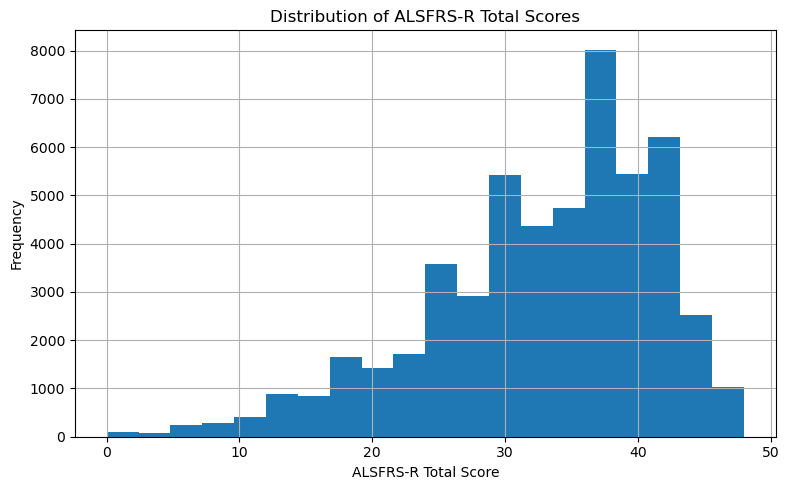

In [44]:
plt.figure(figsize=(8, 5))
week4_df[target_col].hist(bins=20)
plt.xlabel("ALSFRS-R Total Score")
plt.ylabel("Frequency")
plt.title("Distribution of ALSFRS-R Total Scores")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week4_alsfrs_distribution.png", dpi=300)
plt.show()

In [45]:
sample_patients = (
    visit_counts.sort_values("num_rows_per_patient", ascending=False)
    .head(10)[patient_col]
    .tolist()
)

traj_df = week4_df[week4_df[patient_col].isin(sample_patients)].copy()
traj_df.head()

,subject_id,alsfrs_delta,alsfrs_r_total
3837,465833,4.0,29.0
3838,465833,56.0,27.0
3839,465833,140.0,29.0
3840,465833,196.0,28.0
3841,465833,253.0,30.0


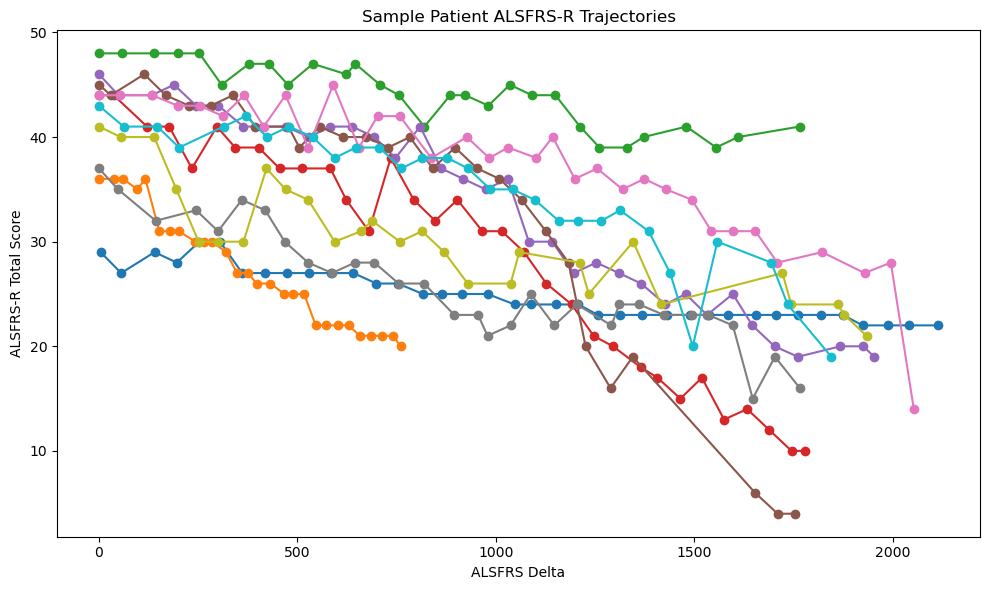

In [46]:
plt.figure(figsize=(10, 6))

for pid, group in traj_df.groupby(patient_col):
    group = group.sort_values(time_col)
    plt.plot(group[time_col], group[target_col], marker="o")

plt.xlabel("ALSFRS Delta")
plt.ylabel("ALSFRS-R Total Score")
plt.title("Sample Patient ALSFRS-R Trajectories")
plt.tight_layout()
plt.savefig(repo_root / "figures" / "week4_patient_trajectories.png", dpi=300)
plt.show()

In [48]:
week4_df.to_csv(repo_root / "data" / "processed" / "alsfrs_longitudinal_week4.csv", index=False)